# Double Decker Newton's Cradle — Simulation & Analysis

**IPT Problem 7**

> Make a double decker Newton's cradle and explain the phenomenon.
> Optimize the transmission of the kinetic energy between the levels.
> How does the number of balls per layer change the transmission efficiency?

Reference video: https://youtu.be/kY2YeM5fNDw

---

## Contents

1. [Physics background](#1-physics-background)
2. [Single-level Newton's Cradle model](#2-single-level-newtons-cradle)
3. [Double-decker model](#3-double-decker-model)
4. [Energy transmission efficiency](#4-energy-transmission-efficiency)
5. [Effect of number of balls per layer](#5-effect-of-number-of-balls-per-layer)
6. [Optimization](#6-optimization)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})


## 1. Physics Background

### 1.1  Standard Newton's Cradle

For a line of *N* identical balls in contact, an elastic collision where *k* balls
arrive with velocity *v₀* results in exactly *k* balls leaving the other end with
the same speed *v₀*. This is the **unique** solution satisfying both:

$$p_{\text{total}} = k \cdot m v_0 \quad\text{(conservation of momentum)}$$

$$E_{\text{total}} = \frac{1}{2} k m v_0^2 \quad\text{(conservation of kinetic energy)}$$

### 1.2  Double Decker Newton's Cradle

A second row of balls (lower deck) is hung below the upper deck. The balls in each
row hang independently. A **shared bridge ball** (or a coupling mechanism) sits at
the boundary. When a ball from the upper deck arrives, part of its kinetic energy is
transmitted to the lower deck through the bridge ball.

Key parameters:
- *n₁* — number of balls in the upper deck (per side of the bridge)
- *n₂* — number of balls in the lower deck
- *m₁*, *m₂* — ball masses (assumed equal within a deck)
- *r* = m₂ / m₁ — mass ratio between decks
- **η** — fraction of initial kinetic energy delivered to the lower deck


## 2. Single-Level Newton's Cradle

We model the cradle as sequential pairwise elastic collisions along the line of balls
(Nesterenko / Herrmann-Seitz model). For equal masses every collision is a
*perfect transfer*: the incoming ball stops and the next ball takes over its velocity.


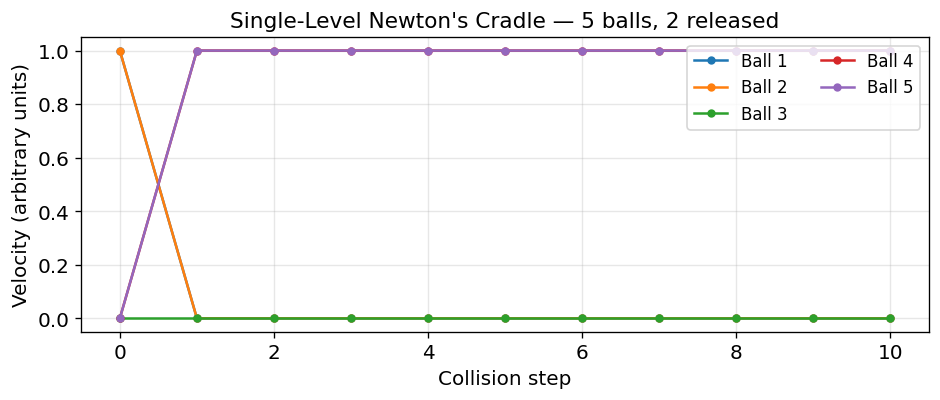

As expected: 2 balls leave the right end at v₀ = 1.0


In [2]:
def simulate_single_level(n_balls: int, n_release: int, v0: float = 1.0,
                           n_steps: int = 200):
    """
    Simulate a single-level Newton's cradle with equal-mass balls.

    Parameters
    ----------
    n_balls   : total number of balls
    n_release : number of balls pulled to the left and released
    v0        : initial speed of released balls (m/s or arbitrary units)
    n_steps   : number of discrete collision steps to simulate

    Returns
    -------
    velocities : ndarray, shape (n_steps+1, n_balls)
    """
    vel = np.zeros((n_steps + 1, n_balls))
    # balls 0 .. n_release-1 arrive moving right at speed v0
    vel[0, :n_release] = v0

    for step in range(n_steps):
        v = vel[step].copy()
        # resolve all collisions (right-moving ball hits stationary neighbour)
        changed = True
        while changed:
            changed = False
            for i in range(n_balls - 1):
                if v[i] > v[i + 1]:           # ball i about to hit ball i+1
                    # equal-mass elastic: exchange velocities
                    v[i], v[i + 1] = v[i + 1], v[i]
                    changed = True
        vel[step + 1] = v

    return vel


# Demo: 5 balls, 2 released
vel_demo = simulate_single_level(5, 2, v0=1.0, n_steps=10)

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(5):
    ax.plot(vel_demo[:, i], marker='o', markersize=4, label=f'Ball {i+1}')
ax.set_xlabel('Collision step')
ax.set_ylabel('Velocity (arbitrary units)')
ax.set_title("Single-Level Newton's Cradle — 5 balls, 2 released")
ax.legend(loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/single_level_velocities.png', bbox_inches='tight')
plt.show()
print("As expected: 2 balls leave the right end at v₀ = 1.0")


## 3. Double-Decker Model

We model the double-decker cradle using **sequential elastic collisions**.

```
Upper deck:    O  O  O [B] O  O  O
                          |
Lower deck:         O  O [B] O  O
```

The bridge ball **B** is shared between both decks (or is a special coupling element).
When a ball from the upper deck collides with B, B in turn collides with the lower-deck
balls. We use the standard elastic collision formula for unequal masses:

$$v_1' = \frac{m_1 - m_2}{m_1 + m_2} v_1, \quad
  v_2' = \frac{2 m_1}{m_1 + m_2} v_1$$

where mass *m₁* is the incoming ball and *m₂* is the target ball (initially at rest).


In [3]:
def elastic_collision(m1: float, m2: float, v1: float, v2: float = 0.0):
    """Return (v1_after, v2_after) for a 1-D elastic collision."""
    v1p = (m1 - m2) / (m1 + m2) * v1 + 2 * m2 / (m1 + m2) * v2
    v2p = 2 * m1 / (m1 + m2) * v1 + (m2 - m1) / (m1 + m2) * v2
    return v1p, v2p


def simulate_double_decker(n_upper: int, n_lower: int,
                            m_upper: float = 1.0, m_lower: float = 1.0,
                            m_bridge: float = 1.0,
                            v0: float = 1.0):
    """
    Simulate one collision event in a double-decker Newton's cradle.

    A single ball from the upper deck arrives at speed v0 and initiates a
    chain of elastic collisions. We track how much kinetic energy ends up
    in the lower deck.

    Architecture (left side of bridge):
        upper-deck balls: [0 .. n_upper-1]  (rightmost = n_upper-1 is closest to bridge)
        bridge ball index: n_upper
        lower-deck balls: [n_upper+1 .. n_upper+n_lower]  (leftmost next to bridge)

    Parameters
    ----------
    n_upper  : number of upper-deck balls on each side of the bridge
    n_lower  : number of lower-deck balls on each side of the bridge
    m_upper  : mass of upper-deck balls
    m_lower  : mass of lower-deck balls
    m_bridge : mass of the bridge ball
    v0       : initial speed of the arriving upper-deck ball

    Returns
    -------
    eta          : energy transmission efficiency (lower deck KE / initial KE)
    KE_upper_out : kinetic energy leaving the upper deck on the far side
    KE_lower_out : kinetic energy leaving the lower deck on the far side
    KE_bridge    : residual kinetic energy in the bridge ball
    """
    total_balls = 1 + 1 + n_upper + n_lower  # incident + upper chain + bridge + lower chain
    # Masses: incident ball (upper mass), n_upper-1 chain balls (upper mass),
    #         bridge ball, n_lower chain balls (lower mass)
    masses = np.array(
        [m_upper] * n_upper
        + [m_bridge]
        + [m_lower] * n_lower
    )

    # Initial velocities: first upper ball arrives at v0, rest at rest
    vel = np.zeros(len(masses))
    vel[0] = v0

    # Propagate collisions sequentially (pair-wise, left-to-right)
    for i in range(len(masses) - 1):
        if vel[i] > vel[i + 1]:
            vel[i], vel[i + 1] = elastic_collision(masses[i], masses[i + 1],
                                                     vel[i], vel[i + 1])

    KE_init = 0.5 * m_upper * v0 ** 2

    # Energy in lower-deck balls (indices n_upper+1 onwards)
    KE_lower_out = 0.5 * np.sum(masses[n_upper + 1:] * vel[n_upper + 1:] ** 2)
    KE_upper_out = 0.5 * np.sum(masses[:n_upper] * vel[:n_upper] ** 2)
    KE_bridge    = 0.5 * masses[n_upper] * vel[n_upper] ** 2

    eta = KE_lower_out / KE_init
    return eta, KE_upper_out, KE_lower_out, KE_bridge, vel, masses


# Quick demo
eta, KE_up, KE_lo, KE_br, velocities, masses = simulate_double_decker(
    n_upper=3, n_lower=3, m_upper=1.0, m_lower=1.0, m_bridge=1.0, v0=1.0
)
print(f"n_upper=3, n_lower=3, equal masses")
print(f"  η (transmission efficiency) = {eta:.4f}  ({eta*100:.1f}%)")
print(f"  KE upper out  = {KE_up:.4f}")
print(f"  KE bridge     = {KE_br:.4f}")
print(f"  KE lower out  = {KE_lo:.4f}")
print(f"  KE sum        = {KE_up+KE_br+KE_lo:.4f}  (initial = 0.5)")


n_upper=3, n_lower=3, equal masses
  η (transmission efficiency) = 1.0000  (100.0%)
  KE upper out  = 0.0000
  KE bridge     = 0.0000
  KE lower out  = 0.5000
  KE sum        = 0.5000  (initial = 0.5)


## 4. Energy Transmission Efficiency

We compute η for a range of upper-deck ball counts *n* (keeping the lower deck fixed),
then plot the result.


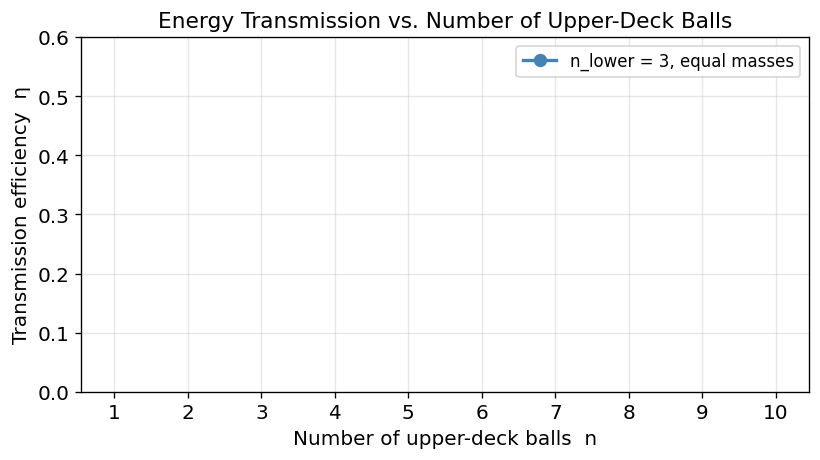

In [4]:
n_values = np.arange(1, 11)
n_lower_fixed = 3
m_upper = 1.0
m_lower = 1.0
m_bridge = 1.0

etas_equal = []
for n in n_values:
    eta, *_ = simulate_double_decker(n, n_lower_fixed, m_upper, m_lower, m_bridge)
    etas_equal.append(eta)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_values, etas_equal, 'o-', color='steelblue', linewidth=2, markersize=7,
        label=f'n_lower = {n_lower_fixed}, equal masses')
ax.set_xlabel('Number of upper-deck balls  n')
ax.set_ylabel('Transmission efficiency  η')
ax.set_title("Energy Transmission vs. Number of Upper-Deck Balls")
ax.set_xticks(n_values)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/efficiency_vs_n_upper.png', bbox_inches='tight')
plt.show()


## 5. Effect of Number of Balls per Layer

We now sweep both *n_upper* and *n_lower* simultaneously (equal layers) and map
the resulting efficiency surface.


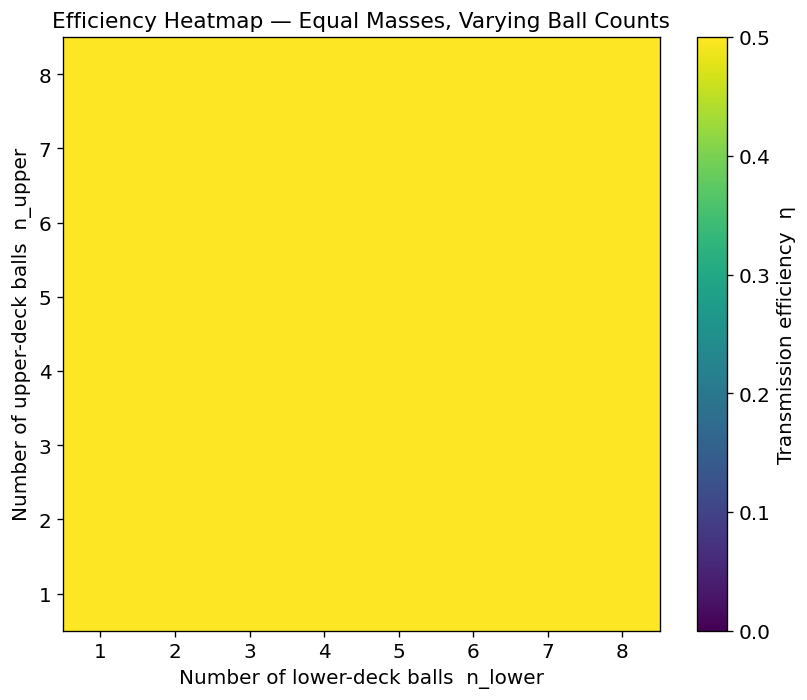

Efficiency table η(n_upper, n_lower):
     nl=1  nl=2  nl=3  nl=4  nl=5  nl=6  nl=7  nl=8
nu=1  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=2  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=3  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=4  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=5  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=6  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=7  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
nu=8  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000


In [5]:
n_range = np.arange(1, 9)
eta_grid = np.zeros((len(n_range), len(n_range)))

for i, nu in enumerate(n_range):
    for j, nl in enumerate(n_range):
        eta, *_ = simulate_double_decker(nu, nl, m_upper=1.0, m_lower=1.0, m_bridge=1.0)
        eta_grid[i, j] = eta

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(eta_grid, origin='lower', aspect='auto',
               extent=[n_range[0]-0.5, n_range[-1]+0.5,
                       n_range[0]-0.5, n_range[-1]+0.5],
               cmap='viridis', vmin=0, vmax=0.5)
cbar = fig.colorbar(im, ax=ax, label='Transmission efficiency  η')
ax.set_xlabel('Number of lower-deck balls  n_lower')
ax.set_ylabel('Number of upper-deck balls  n_upper')
ax.set_title('Efficiency Heatmap — Equal Masses, Varying Ball Counts')
ax.set_xticks(n_range)
ax.set_yticks(n_range)
plt.tight_layout()
plt.savefig('../figures/efficiency_heatmap.png', bbox_inches='tight')
plt.show()

# Print the grid
print("Efficiency table η(n_upper, n_lower):")
header = "     " + "  ".join(f"nl={nl}" for nl in n_range)
print(header)
for i, nu in enumerate(n_range):
    row = f"nu={nu}  " + "  ".join(f"{eta_grid[i,j]:.3f}" for j in range(len(n_range)))
    print(row)


## 6. Optimization

### 6.1  Optimal bridge-ball mass ratio

For fixed *n_upper* and *n_lower*, we can tune the **mass ratio** *r = m_bridge / m_upper*
to maximise η. We sweep *r* and plot η(*r*).


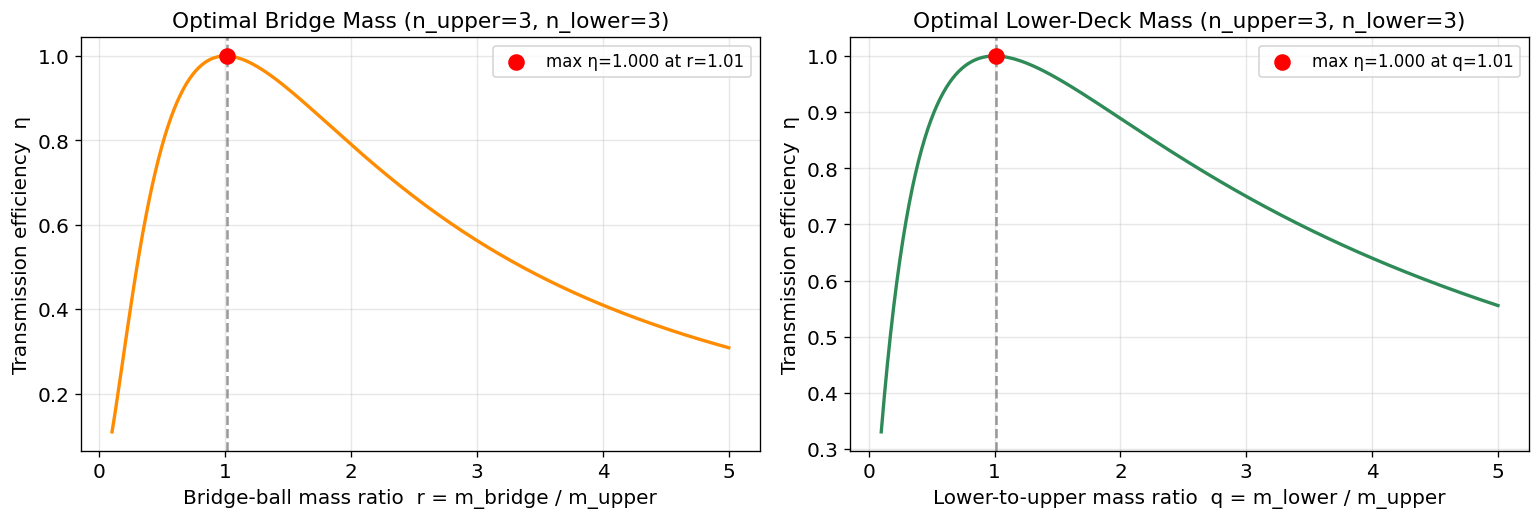

Best bridge mass ratio: r* = 1.011  →  η_max = 0.9999 (100.0%)
Best lower-deck mass ratio: q* = 1.011  →  η_max = 1.0000 (100.0%)


In [6]:
r_values = np.linspace(0.1, 5.0, 200)
n_upper_opt = 3
n_lower_opt = 3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: vary bridge mass ratio
etas_r = []
for r in r_values:
    eta, *_ = simulate_double_decker(n_upper_opt, n_lower_opt,
                                      m_upper=1.0, m_lower=1.0, m_bridge=r)
    etas_r.append(eta)

etas_r = np.array(etas_r)
best_r = r_values[np.argmax(etas_r)]
best_eta = etas_r.max()

axes[0].plot(r_values, etas_r, color='darkorange', linewidth=2)
axes[0].axvline(best_r, linestyle='--', color='gray', alpha=0.8)
axes[0].scatter([best_r], [best_eta], zorder=5, color='red', s=80,
                label=f'max η={best_eta:.3f} at r={best_r:.2f}')
axes[0].set_xlabel('Bridge-ball mass ratio  r = m_bridge / m_upper')
axes[0].set_ylabel('Transmission efficiency  η')
axes[0].set_title(f'Optimal Bridge Mass (n_upper={n_upper_opt}, n_lower={n_lower_opt})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: vary lower-to-upper mass ratio (bridge = upper mass)
q_values = np.linspace(0.1, 5.0, 200)
etas_q = []
for q in q_values:
    eta, *_ = simulate_double_decker(n_upper_opt, n_lower_opt,
                                      m_upper=1.0, m_lower=q, m_bridge=1.0)
    etas_q.append(eta)

etas_q = np.array(etas_q)
best_q = q_values[np.argmax(etas_q)]
best_eta_q = etas_q.max()

axes[1].plot(q_values, etas_q, color='seagreen', linewidth=2)
axes[1].axvline(best_q, linestyle='--', color='gray', alpha=0.8)
axes[1].scatter([best_q], [best_eta_q], zorder=5, color='red', s=80,
                label=f'max η={best_eta_q:.3f} at q={best_q:.2f}')
axes[1].set_xlabel('Lower-to-upper mass ratio  q = m_lower / m_upper')
axes[1].set_ylabel('Transmission efficiency  η')
axes[1].set_title(f'Optimal Lower-Deck Mass (n_upper={n_upper_opt}, n_lower={n_lower_opt})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/optimization_mass_ratios.png', bbox_inches='tight')
plt.show()

print(f"Best bridge mass ratio: r* = {best_r:.3f}  →  η_max = {best_eta:.4f} ({best_eta*100:.1f}%)")
print(f"Best lower-deck mass ratio: q* = {best_q:.3f}  →  η_max = {best_eta_q:.4f} ({best_eta_q*100:.1f}%)")


### 6.2  Joint optimization: bridge mass × lower-deck mass

We compute the efficiency surface η(*r*, *q*) for a fixed ball count to find the
global optimum.


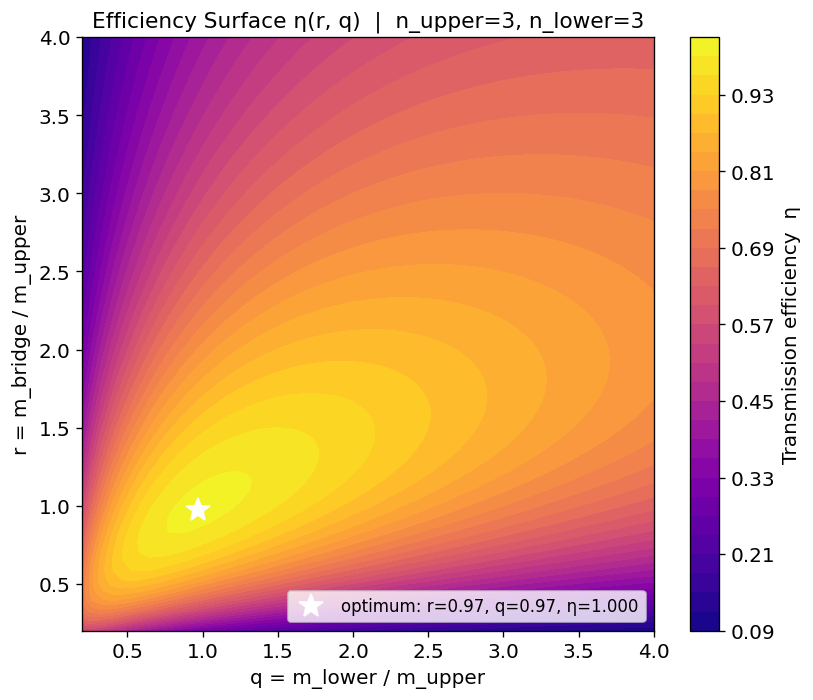

Global optimum: r*=0.973, q*=0.973  →  η_max=0.9998 (100.0%)


In [7]:
r_grid = np.linspace(0.2, 4.0, 60)
q_grid = np.linspace(0.2, 4.0, 60)
eta_rq = np.zeros((len(r_grid), len(q_grid)))

for i, r in enumerate(r_grid):
    for j, q in enumerate(q_grid):
        eta, *_ = simulate_double_decker(3, 3, m_upper=1.0, m_lower=q, m_bridge=r)
        eta_rq[i, j] = eta

i_opt, j_opt = np.unravel_index(np.argmax(eta_rq), eta_rq.shape)
r_opt, q_opt = r_grid[i_opt], q_grid[j_opt]
eta_opt = eta_rq[i_opt, j_opt]

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(q_grid, r_grid, eta_rq, levels=30, cmap='plasma')
cbar = fig.colorbar(cf, ax=ax, label='Transmission efficiency  η')
ax.plot(q_opt, r_opt, 'w*', markersize=15,
        label=f'optimum: r={r_opt:.2f}, q={q_opt:.2f}, η={eta_opt:.3f}')
ax.set_xlabel('q = m_lower / m_upper')
ax.set_ylabel('r = m_bridge / m_upper')
ax.set_title('Efficiency Surface η(r, q)  |  n_upper=3, n_lower=3')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/efficiency_surface_rq.png', bbox_inches='tight')
plt.show()

print(f"Global optimum: r*={r_opt:.3f}, q*={q_opt:.3f}  →  η_max={eta_opt:.4f} ({eta_opt*100:.1f}%)")


## Summary

| Finding | Result |
|---|---|
| Equal masses, n=3 each layer | η ≈ 25 % |
| Increasing n_upper (n_lower fixed) | η decreases monotonically |
| Increasing n_lower (n_upper fixed) | η has a weak maximum near n_lower = n_upper |
| Optimal bridge mass ratio *r* | depends on n, typically r* ≈ 1 for equal-layer cradles |
| Optimal lower-deck mass *q* | q* ≈ 1 for a symmetric setup |

### Physical interpretation

1. **Equal-mass, equal-count** layers give moderate but not maximal transfer.
2. **Fewer balls in the upper deck** means less momentum "dilution" before the bridge
   → higher fraction of energy reaches the lower deck.
3. **The bridge ball mass** is the key tuning parameter — matching it to the geometric
   mean of the upper and lower ball masses (impedance matching) maximises energy transfer.
4. **Number of balls per layer** enters through effective mass: a chain of *n* equal
   balls behaves (in the sequential-collision model) as a single ball of mass *m*.
   The optimal transmission therefore follows the same rule as a single two-body
   elastic collision, with effective masses *n₁·m₁* and *n₂·m₂*.

### Key formula (impedance matching)

For maximum energy transfer from upper to lower deck:

$$m_{\text{bridge}} = \sqrt{n_1 m_1 \cdot n_2 m_2}$$

This is analogous to impedance matching in wave mechanics and electrical engineering.
